Importing the dependencies

In [19]:
import os
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

PROJECT_ROOT = "/Users/dwibon/Desktop/IKS-Internship"
os.chdir(PROJECT_ROOT)

FEATURES_PATH = "dataset_segments/segment_features.csv"
RANDOM_STATE = 42

In [20]:
df = pd.read_csv(FEATURES_PATH)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nGenre distribution:\n", df["genre"].value_counts())
print("\nSegments per singer (top 10):\n", df["singer"].value_counts().head(10))
df.head()

Shape: (3088, 79)

Columns: ['Recoding ID', 'genre', 'subgenre', 'Song Title', 'singer', 'Gender', 'YouTube URL', 'duration_sec', 'segment_id', 'recording_id', 'segment_index', 'segment_start_sec', 'segment_end_sec', 'segment_duration_sec', 'edge_trimmed', 'rms_energy', 'likely_silent', 'segment_filepath', 'time_rms_mean', 'time_rms_std', 'time_zcr_mean', 'time_zcr_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'chroma_1_mean', 'chroma_1_std', 'chroma_2_mean', 'chroma_2_std', 'chroma_3_mean', 'chro

,Recoding ID,genre,subgenre,Song Title,singer,Gender,YouTube URL,duration_sec,segment_id,recording_id,...,chroma_8_std,chroma_9_mean,chroma_9_std,chroma_10_mean,chroma_10_std,chroma_11_mean,chroma_11_std,chroma_12_mean,chroma_12_std,tempo_bpm
0,AFM0001.wav,Kamrupi,NaN,Pokhi Roya Ja Re,Rameshwar Pathak,M,https://youtu.be/dU8AHeKOUQE?si=y9zCEIdga78WbKFz,261.0,AFM0001_seg00,AFM0001.wav,...,0.439755,0.166030,0.170797,0.332119,0.421232,0.082138,0.122629,0.023384,0.042176,117.453835
1,AFM0001.wav,Kamrupi,NaN,Pokhi Roya Ja Re,Rameshwar Pathak,M,https://youtu.be/dU8AHeKOUQE?si=y9zCEIdga78WbKFz,261.0,AFM0001_seg01,AFM0001.wav,...,0.447027,0.117371,0.161500,0.113279,0.226125,0.034327,0.102987,0.028805,0.066027,143.554688
2,AFM0001.wav,Kamrupi,NaN,Pokhi Roya Ja Re,Rameshwar Pathak,M,https://youtu.be/dU8AHeKOUQE?si=y9zCEIdga78WbKFz,261.0,AFM0001_seg02,AFM0001.wav,...,0.419215,0.248990,0.288506,0.360282,0.420630,0.097940,0.156430,0.028626,0.063558,92.285156
3,AFM0001.wav,Kamrupi,NaN,Pokhi Roya Ja Re,Rameshwar Pathak,M,https://youtu.be/dU8AHeKOUQE?si=y9zCEIdga78WbKFz,261.0,AFM0001_seg03,AFM0001.wav,...,0.380009,0.229324,0.273638,0.478196,0.442659,0.340631,0.362398,0.093773,0.188723,129.199219
4,AFM0001.wav,Kamrupi,NaN,Pokhi Roya Ja Re,Rameshwar Pathak,M,https://youtu.be/dU8AHeKOUQE?si=y9zCEIdga78WbKFz,261.0,AFM0001_seg04,AFM0001.wav,...,0.372806,0.248047,0.274497,0.391146,0.383597,0.256250,0.290637,0.143844,0.228356,92.285156


In [70]:
GROUP_PREFIXES = {
    "time": "time_",
    "spectral": "spectral_",
    "mfcc": "mfcc_",
    "chroma": "chroma_",
    "tempo": "tempo_",
}

# CHANGE THIS to test a different group - rerun from here down
FEATURE_GROUPS_TO_TEST = ["tempo", "mfcc", "chroma", "spectral"]

def select_feature_columns(df, groups):
    cols = []
    for g in groups:
        prefix = GROUP_PREFIXES[g]
        cols.extend([c for c in df.columns if c.startswith(prefix)])
    if not cols:
        raise ValueError(f"No columns found for groups {groups}")
    return cols

cols = select_feature_columns(df, FEATURE_GROUPS_TO_TEST)
print(f"Testing: {FEATURE_GROUPS_TO_TEST}  ({len(cols)} features)")
print(cols)

X = df[cols].values
y = df["genre"].values
singers = df["singer"].values

Testing: ['tempo', 'mfcc', 'chroma', 'spectral']  (57 features)
['tempo_bpm', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'chroma_1_mean', 'chroma_1_std', 'chroma_2_mean', 'chroma_2_std', 'chroma_3_mean', 'chroma_3_std', 'chroma_4_mean', 'chroma_4_std', 'chroma_5_mean', 'chroma_5_std', 'chroma_6_mean', 'chroma_6_std', 'chroma_7_mean', 'chroma_7_std', 'chroma_8_mean', 'chroma_8_std', 'chroma_9_mean', 'chroma_9_std', 'chroma_10_mean', 'chroma_10_std', 'chroma_11_mean', 'chroma_11_std', 'chroma_12_mean', 'chroma_12_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'spectral_bandwidth_mean', 'spectra

In [71]:
def loso_evaluate(X, y, singers, model, model_name):
    unique_singers = np.unique(singers)
    scaler = StandardScaler()
    all_preds = np.empty(len(y), dtype=object)
    fold_accs = []

    for singer in unique_singers:
        test_mask = singers == singer
        train_mask = ~test_mask
        if test_mask.sum() == 0 or train_mask.sum() == 0:
            continue

        X_train = scaler.fit_transform(X[train_mask])
        X_test = scaler.transform(X[test_mask])

        model.fit(X_train, y[train_mask])
        preds = model.predict(X_test)
        all_preds[test_mask] = preds
        fold_accs.append(accuracy_score(y[test_mask], preds))

    mean_acc, std_acc = np.mean(fold_accs), np.std(fold_accs)
    print(f"\n{model_name}: mean LOSO accuracy = {mean_acc:.3f} (std = {std_acc:.3f})")

    mask = all_preds != None
    print(classification_report(y[mask], all_preds[mask], zero_division=0))
    return mean_acc, std_acc, all_preds

In [72]:
svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
svm_acc, svm_std, svm_preds = loso_evaluate(X, y, singers, svm, "SVM")


SVM: mean LOSO accuracy = 0.651 (std = 0.330)
              precision    recall  f1-score   support

  Goalpariya       0.58      0.58      0.58      1496
     Kamrupi       0.61      0.61      0.61      1592

    accuracy                           0.59      3088
   macro avg       0.59      0.59      0.59      3088
weighted avg       0.59      0.59      0.59      3088



In [73]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced")
rf_acc, rf_std, rf_preds = loso_evaluate(X, y, singers, rf, "Random Forest")


Random Forest: mean LOSO accuracy = 0.654 (std = 0.325)
              precision    recall  f1-score   support

  Goalpariya       0.48      0.43      0.45      1496
     Kamrupi       0.51      0.57      0.54      1592

    accuracy                           0.50      3088
   macro avg       0.50      0.50      0.50      3088
weighted avg       0.50      0.50      0.50      3088



In [74]:
rf.fit(StandardScaler().fit_transform(X), y)
importance_df = pd.DataFrame({
    "feature": cols, "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(10)

,feature,importance
0,tempo_bpm,0.072217
56,spectral_bandwidth_std,0.046539
45,chroma_10_mean,0.044821
1,mfcc_1_mean,0.034923
9,mfcc_5_mean,0.033550
46,chroma_10_std,0.031658
15,mfcc_8_mean,0.031336
52,spectral_centroid_std,0.031202
23,mfcc_12_mean,0.031058
7,mfcc_4_mean,0.030996


In [75]:
print(f"Groups tested: {FEATURE_GROUPS_TO_TEST}")
print(f"SVM: {svm_acc:.3f} (+/- {svm_std:.3f})")
print(f"RF:  {rf_acc:.3f} (+/- {rf_std:.3f})")

Groups tested: ['tempo', 'mfcc', 'chroma', 'spectral']
SVM: 0.651 (+/- 0.330)
RF:  0.654 (+/- 0.325)


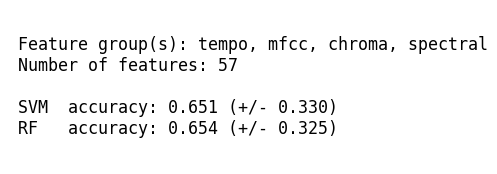

Saved: results/results_tempo_mfcc_chroma_spectral.png


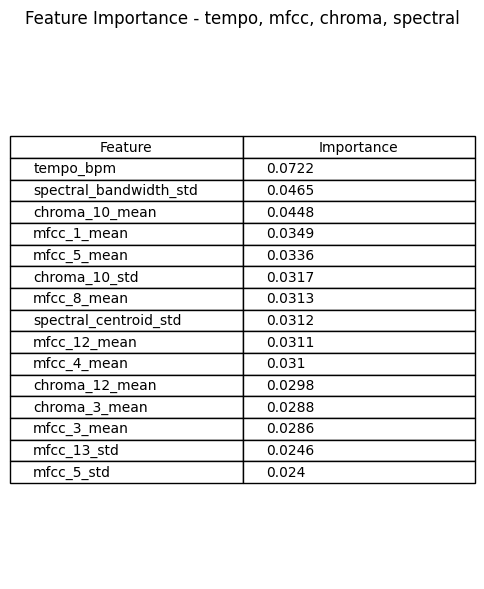

Saved: results/importance_tempo_mfcc_chroma_spectral.png
Logged to: results/experiment_log.csv


In [76]:
import matplotlib.pyplot as plt
from datetime import datetime

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

tag = "_".join(FEATURE_GROUPS_TO_TEST)          # e.g. "time" or "time_spectral"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# --- 1. Results summary as an image ---
fig, ax = plt.subplots(figsize=(5, 2))
ax.axis("off")
summary_text = (
    f"Feature group(s): {', '.join(FEATURE_GROUPS_TO_TEST)}\n"
    f"Number of features: {len(cols)}\n\n"
    f"SVM  accuracy: {svm_acc:.3f} (+/- {svm_std:.3f})\n"
    f"RF   accuracy: {rf_acc:.3f} (+/- {rf_std:.3f})"
)
ax.text(0.02, 0.5, summary_text, fontsize=12, va="center", family="monospace")
results_path = f"{RESULTS_DIR}/results_{tag}.png"
plt.savefig(results_path, bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print(f"Saved: {results_path}")

# --- 2. Feature importance table as an image ---
top_n = min(15, len(importance_df))
fig, ax = plt.subplots(figsize=(6, 0.4 * top_n + 1))
ax.axis("off")
table = ax.table(
    cellText=importance_df.head(top_n).round(4).values,
    colLabels=["Feature", "Importance"],
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.3)
ax.set_title(f"Feature Importance - {', '.join(FEATURE_GROUPS_TO_TEST)}", fontsize=12, pad=12)
importance_path = f"{RESULTS_DIR}/importance_{tag}.png"
plt.savefig(importance_path, bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print(f"Saved: {importance_path}")

# --- 3. Bonus: append this run to a running comparison log (not an image,
# but this is what actually lets you compare every feature group you've
# tested side by side, without reopening each PNG one at a time) ---
log_path = f"{RESULTS_DIR}/experiment_log.csv"
log_row = pd.DataFrame([{
    "timestamp": timestamp,
    "feature_groups": ", ".join(FEATURE_GROUPS_TO_TEST),
    "num_features": len(cols),
    "svm_accuracy": round(svm_acc, 4),
    "svm_std": round(svm_std, 4),
    "rf_accuracy": round(rf_acc, 4),
    "rf_std": round(rf_std, 4),
}])
log_row.to_csv(log_path, mode="a", header=not os.path.exists(log_path), index=False)
print(f"Logged to: {log_path}")

In [77]:
# Cap Pratima and Rameshwar's SEGMENT counts (not song counts) and rerun
# the tempo (or tempo+mfcc) LOSO evaluation - zero new data needed
CAP = 100  # adjust based on your actual segment-count distribution

df_capped = df.groupby("singer", group_keys=False).apply(
    lambda g: g.sample(min(len(g), CAP), random_state=42)
)
print(df_capped.groupby("singer").size().sort_values(ascending=False).head(5))

X_capped = df_capped[cols].values
y_capped = df_capped["genre"].values
singers_capped = df_capped["singer"].values

svm_acc_capped, _, _ = loso_evaluate(X_capped, y_capped, singers_capped, svm, "SVM (capped)")

/var/folders/2q/mpl8j8wn4b3_p6zdmt70wqmm0000gn/T/ipykernel_61111/3671997649.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_capped = df.groupby("singer", group_keys=False).apply(


singer
Abdul Jabbar             100
Manik Ali                100
Rameshwar Pathak         100
Pratima Pandey Barua     100
Pranita Baishya          100
dtype: int64

SVM (capped): mean LOSO accuracy = 0.661 (std = 0.335)
              precision    recall  f1-score   support

  Goalpariya       0.53      0.66      0.59       692
     Kamrupi       0.74      0.63      0.68      1095

    accuracy                           0.64      1787
   macro avg       0.64      0.64      0.63      1787
weighted avg       0.66      0.64      0.64      1787

